# Setup Imports

In [2]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
import numpy as np

# Load the dataset 

In [4]:
# The file yeast.csv was downloaded from https://www.kaggle.com/datasets/samanemami/yeastcsv?resource=download 

# Load the CSV file
df = pd.read_csv("yeast.csv")

# View first few rows
df.head()


,mcg,gvh,alm,mit,erl,pox,vac,nuc,name
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


# Exploratory Data Analysis

## Inspect the dataframe

In [5]:
# Shape of the dataframe (rows, columns)
df.shape

(1484, 9)

In [6]:
# Data types and non-null counts for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     1484 non-null   float64
 1   gvh     1484 non-null   float64
 2   alm     1484 non-null   float64
 3   mit     1484 non-null   float64
 4   erl     1484 non-null   float64
 5   pox     1484 non-null   float64
 6   vac     1484 non-null   float64
 7   nuc     1484 non-null   float64
 8   name    1484 non-null   str    
dtypes: float64(8), str(1)
memory usage: 104.5 KB


In [7]:
# Summary statistics for numeric columns
df.describe()

,mcg,gvh,alm,mit,erl,pox,vac,nuc
count,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000,1484.000000
mean,0.500121,0.499933,0.500034,0.261186,0.504717,0.007500,0.499885,0.276199
std,0.137299,0.123924,0.086670,0.137098,0.048351,0.075683,0.057797,0.106491
min,0.110000,0.130000,0.210000,0.000000,0.500000,0.000000,0.000000,0.000000
25%,0.410000,0.420000,0.460000,0.170000,0.500000,0.000000,0.480000,0.220000
50%,0.490000,0.490000,0.510000,0.220000,0.500000,0.000000,0.510000,0.220000
75%,0.580000,0.570000,0.550000,0.320000,0.500000,0.000000,0.530000,0.300000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.830000,0.730000,1.000000


## Class Distribution

In [8]:
# Count of proteins in each localization class
df["name"].value_counts()

name
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
ERL      5
Name: count, dtype: int64

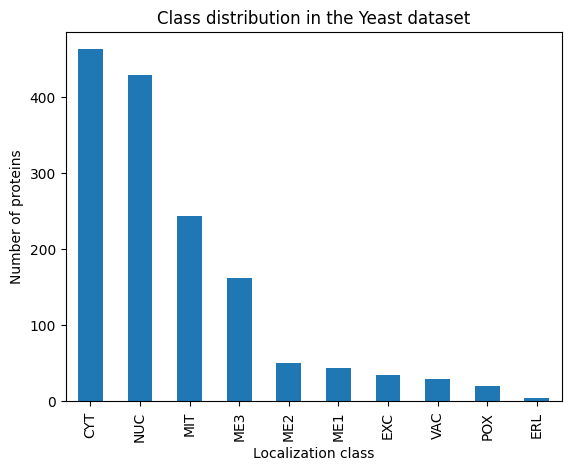

In [9]:
# Bar chart of class distribution
df["name"].value_counts().plot(kind="bar")
plt.xlabel("Localization class")
plt.ylabel("Number of proteins")
plt.title("Class distribution in the Yeast dataset")
plt.show()

### Note that ERL having only 5 samples is going to be an issue for analysis

# Dataset Description


## Dependent variable (target)

**`name`** — the protein's subcellular localization, one of 10 compartments inside the yeast cell:

| Class | Full name | What it is |
|---|---|---|
| **CYT** | Cytosol | The fluid filling the cell (outside organelles). General-purpose space. |
| **NUC** | Nucleus | Where the DNA is stored. |
| **MIT** | Mitochondrion | The "powerhouse" — makes energy (ATP) for the cell. |
| **ME1** | Membrane protein, no signal cleaved | Sits in a membrane, anchored a certain way. |
| **ME2** | Membrane protein, uncleaved signal | Sits in a membrane, anchored a different way. |
| **ME3** | Membrane protein, cleaved signal | Sits in a membrane, anchored a third way. |
| **EXC** | Extracellular | Sent OUT of the cell entirely. |
| **VAC** | Vacuole | Storage tank — holds water, nutrients, waste. |
| **POX** | Peroxisome | Specialized organelle that breaks down fatty acids and toxins. |
| **ERL** | Endoplasmic Reticulum (lumen) | Tube/sac network where proteins are folded and modified. |

## Independent variables (features)

Each feature is a number between 0 and 1 produced by an algorithm that scans the protein's amino acid sequence looking for a specific signal. Think of each one as a "detector" tuned to find a particular molecular address tag.

| Feature | What it detects | Plain English |
|---|---|---|
| **mcg** | McGeoch's signal sequence score | "Does this protein have a signal peptide that says 'send me through the secretory pathway'?" Higher = more likely to be secreted/membrane-bound. |
| **gvh** | von Heijne's signal sequence score | Same idea as `mcg`, but a different (more refined) algorithm. Two ways to detect the same tag. |
| **alm** | ALOM membrane spanning score | "Does this protein have hydrophobic regions long enough to cross a membrane?" Higher = more likely to be a membrane protein. |
| **mit** | Mitochondrial targeting score | "Does this protein have a mitochondrial address tag at its start?" Higher = more likely mitochondrial. |
| **erl** | HDEL retention signal | "Does this protein end with HDEL (the 'stay in the ER' tag)?" Effectively binary — 1.0 = yes, 0.5 = no. |
| **pox** | Peroxisomal targeting signal score | "Does this protein have a 'send me to peroxisome' tag?" |
| **vac** | Vacuolar discriminator score | A score designed to separate vacuolar proteins from extracellular ones. |
| **nuc** | Nuclear localization score | "Does this protein have a nuclear address tag?" Higher = more likely nuclear. |

The prediction task: given these 8 signal-detection scores for a protein, predict which of the 10 compartments it localizes to.

# Data Preprocessing


## Handle Missing Values

In [10]:
# Check for missing values in each column
df.isna().sum()

mcg     0
gvh     0
alm     0
mit     0
erl     0
pox     0
vac     0
nuc     0
name    0
dtype: int64

In [11]:
# No missing values were found, so no rows need to be dropped.
# We still create df_clean here so later sections operate on a dedicated
# preprocessed dataframe (rather than the raw df).
df_clean = df.dropna().copy()

print("Original shape:", df.shape)
print("Shape after dropping any missing rows:", df_clean.shape)

#If missing values had been present, options would have included dropping rows (dropna), filling with column means (fillna), or interpolation (interpolate)

Original shape: (1484, 9)
Shape after dropping any missing rows: (1484, 9)


## Separate Features and Target

In [12]:

# Separate features from the target.
# The first 8 columns (mcg, gvh, alm, mit, erl, pox, vac, nuc) are features.
# The final column 'name' is the target (localization class).
X = df_clean.iloc[:, :-1]   # all columns except the last
y = df_clean.iloc[:, -1]    # the last column

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:", list(X.columns))

Feature shape: (1484, 8)
Target shape: (1484,)

Features: ['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']


## Scale Features

In [13]:
# Standardize features to zero mean and unit variance.
# This matters for distance-based models (KNN, and Bagging with KNN as the base learner).
# Tree-based models (Random Forest, AdaBoost) are scale-invariant and use the unscaled X.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verification
print("Mean of scaled features (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std of scaled features (should be ~1):", X_scaled.std(axis=0).round(3))

Mean of scaled features (should be ~0): [ 0.  0.  0.  0. -0.  0.  0.  0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## Train/Test Split

In [14]:
# Train/test split. We create both an unscaled split (for tree-based models)
# and a scaled split (for distance-based models) using the same indices,
# guaranteed by using the same random_state.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (1187, 8)
X_test shape: (297, 8)

Training class distribution:
name
CYT    370
NUC    343
MIT    195
ME3    131
ME2     41
ME1     35
EXC     28
VAC     24
POX     16
ERL      4
Name: count, dtype: int64

Test class distribution:
name
CYT    93
NUC    86
MIT    49
ME3    32
ME2    10
ME1     9
EXC     7
VAC     6
POX     4
ERL     1
Name: count, dtype: int64


# Random Forest Model

## Hyperparameter Tuning (Grid Search)

In [15]:
# Define the hyperparameter grid to search over
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

# Initialize the model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Run 5-fold cross-validated grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best CV accuracy:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best CV accuracy: 0.6327021948019714
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}


## Final Model Evaluation

In [16]:
# Pull out the best model from the grid search
best_rf = grid_search.best_estimator_

# Predict on the held-out test set
y_pred_rf = best_rf.predict(X_test)

# Overall accuracy
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)
print("Test Accuracy (Random Forest):", rf_test_accuracy)

# Per-class precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=sorted(y.unique()))
print("\nConfusion Matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm_rf, index=sorted(y.unique()), columns=sorted(y.unique())))

Test Accuracy (Random Forest): 0.6262626262626263

Classification Report:
              precision    recall  f1-score   support

         CYT       0.55      0.67      0.60        93
         ERL       0.00      0.00      0.00         1
         EXC       0.60      0.43      0.50         7
         ME1       0.89      0.89      0.89         9
         ME2       0.44      0.40      0.42        10
         ME3       0.82      0.84      0.83        32
         MIT       0.65      0.57      0.61        49
         NUC       0.63      0.62      0.62        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.63       297
   macro avg       0.56      0.47      0.49       297
weighted avg       0.62      0.63      0.62       297


Confusion Matrix (rows = true, columns = predicted):
     CYT  ERL  EXC  ME1  ME2  ME3  MIT  NUC  POX  VAC
CYT   62    0    0    0    0    0    5   26    0    0
ERL  

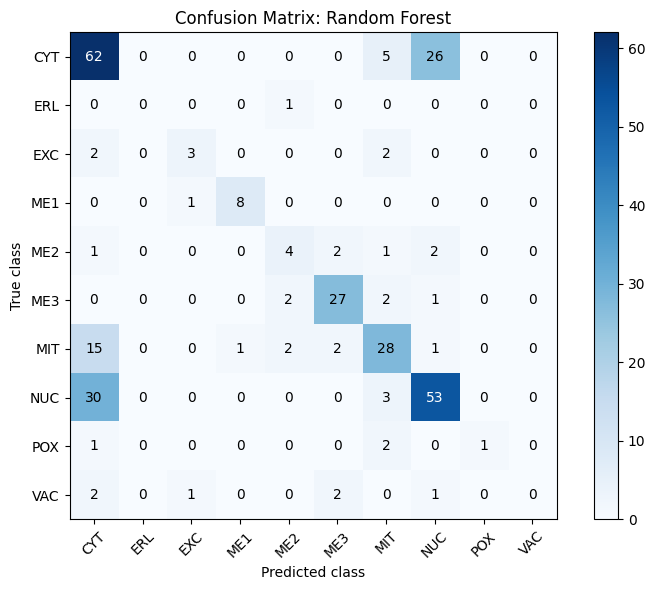

In [17]:
# Plot confusion matrix as a heatmap
class_labels = sorted(y.unique())
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_rf, cmap="Blues")

ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion Matrix: Random Forest")

# Write counts in each cell
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center",
                color="white" if cm_rf[i, j] > cm_rf.max() / 2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

- The CYT/NUC confusion accounts for roughly half of all errors (56 of 111 incorrect predictions), indicating that the model cannot reliably distinguish two classes that overlap heavily in feature space.

- ME1 and ME3 both achieve F1 > 0.80, showing the model can learn distinct membrane-protein subtypes when the feature signal is strong enough.

- Rare classes (ERL, VAC, POX) cannot be reliably predicted with the current dataset size — VAC failed completely (0 of 6 correct) despite having 30 total samples in the dataset.

## Feature Importance

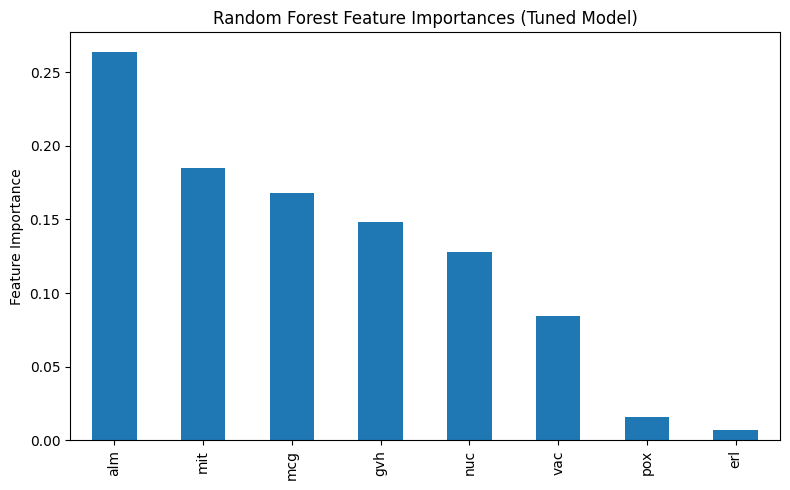

alm    0.263897
mit    0.184746
mcg    0.167923
gvh    0.148399
nuc    0.127789
vac    0.084293
pox    0.015785
erl    0.007167
dtype: float64

In [18]:
# Get feature importances from the tuned model
importances = best_rf.feature_importances_

# Match them to feature names and sort
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
feat_imp.plot(kind="bar")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances (Tuned Model)")
plt.tight_layout()
plt.show()

feat_imp

The Random Forest's feature importance analysis identified alm, mit, mcg, and gvh as the four most influential features, together accounting for approximately 76% of the model's predictive behavior. The remaining four features (nuc, vac, pox, erl) contributed less than a quarter of the model's decisions, with pox and erl being nearly negligible.

# K Nearest Neighbors

## Hyperparameter tuning

In [19]:
# Define the hyperparameter grid to search over
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15, 21],
    "weights": ["uniform", "distance"],
}

# Initialize the model
knn = KNeighborsClassifier()

# Run 5-fold cross-validated grid search.
# Note: KNN uses the SCALED features (X_train_scaled).
knn_grid_search = GridSearchCV(
    estimator=knn,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

knn_grid_search.fit(X_train_scaled, y_train)

print("Best CV accuracy:", knn_grid_search.best_score_)
print("Best parameters:", knn_grid_search.best_params_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best CV accuracy: 0.6158564691699465
Best parameters: {'n_neighbors': 15, 'weights': 'distance'}


In [20]:
# Pull out the best model from the grid search
best_knn = knn_grid_search.best_estimator_

# Predict on the held-out test set (using SCALED features)
y_pred_knn = best_knn.predict(X_test_scaled)

# Overall accuracy
knn_test_accuracy = accuracy_score(y_test, y_pred_knn)
print("Test Accuracy (KNN):", knn_test_accuracy)

# Per-class precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=sorted(y.unique()))
print("\nConfusion Matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm_knn, index=sorted(y.unique()), columns=sorted(y.unique())))

Test Accuracy (KNN): 0.5993265993265994

Classification Report:
              precision    recall  f1-score   support

         CYT       0.55      0.69      0.61        93
         ERL       1.00      1.00      1.00         1
         EXC       0.44      0.57      0.50         7
         ME1       0.80      0.89      0.84         9
         ME2       0.33      0.20      0.25        10
         ME3       0.79      0.72      0.75        32
         MIT       0.63      0.59      0.61        49
         NUC       0.58      0.53      0.56        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.60       297
   macro avg       0.61      0.54      0.55       297
weighted avg       0.59      0.60      0.59       297


Confusion Matrix (rows = true, columns = predicted):
     CYT  ERL  EXC  ME1  ME2  ME3  MIT  NUC  POX  VAC
CYT   64    0    0    0    0    0    5   24    0    0
ERL    0    1  

KNN achieved 60.0% test accuracy, comparable to the Random Forest's 62.6%; both models correctly identified larger and well-defined classes such as CYT, NUC, and ME3 but failed to predict the rare VAC class entirely.

# Bagging 

## Hyperparameter tuning

In [21]:
# Define the hyperparameter grid to search over
bagging_param_grid = {
    "n_estimators": [50, 100],
    "max_samples": [0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0],
}

# Initialize the model with KNN as the base learner
bagging = BaggingClassifier(
    estimator=KNeighborsClassifier(),
    random_state=42,
)

# Run 5-fold cross-validated grid search.
# Note: Bagging with KNN base uses the SCALED features (X_train_scaled).
bagging_grid_search = GridSearchCV(
    estimator=bagging,
    param_grid=bagging_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

bagging_grid_search.fit(X_train_scaled, y_train)

print("Best CV accuracy:", bagging_grid_search.best_score_)
print("Best parameters:", bagging_grid_search.best_params_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best CV accuracy: 0.6090947771513668
Best parameters: {'max_features': 0.75, 'max_samples': 1.0, 'n_estimators': 100}


## Final Model Evaluation

In [22]:
# Pull out the best model from the grid search
best_bagging = bagging_grid_search.best_estimator_

# Predict on the held-out test set (using SCALED features)
y_pred_bagging = best_bagging.predict(X_test_scaled)

# Overall accuracy
bagging_test_accuracy = accuracy_score(y_test, y_pred_bagging)
print("Test Accuracy (Bagging):", bagging_test_accuracy)

# Per-class precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging, zero_division=0))

# Confusion matrix
cm_bagging = confusion_matrix(y_test, y_pred_bagging, labels=sorted(y.unique()))
print("\nConfusion Matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm_bagging, index=sorted(y.unique()), columns=sorted(y.unique())))

Test Accuracy (Bagging): 0.5858585858585859

Classification Report:
              precision    recall  f1-score   support

         CYT       0.52      0.68      0.59        93
         ERL       1.00      1.00      1.00         1
         EXC       0.50      0.57      0.53         7
         ME1       0.80      0.89      0.84         9
         ME2       0.33      0.20      0.25        10
         ME3       0.80      0.75      0.77        32
         MIT       0.64      0.55      0.59        49
         NUC       0.57      0.51      0.54        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.59       297
   macro avg       0.62      0.54      0.55       297
weighted avg       0.58      0.59      0.58       297


Confusion Matrix (rows = true, columns = predicted):
     CYT  ERL  EXC  ME1  ME2  ME3  MIT  NUC  POX  VAC
CYT   63    0    0    0    0    0    5   25    0    0
ERL    0   

Bagging adds nothing useful. Stick with normal KNN if anything.

# AdaBoost

## Hyperparameter Tuning

In [23]:
# Define the hyperparameter grid to search over
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}

# Initialize the model
ada = AdaBoostClassifier(random_state=42)

# Run 5-fold cross-validated grid search.
# Note: AdaBoost uses unscaled features (its base learner is a decision tree).
ada_grid_search = GridSearchCV(
    estimator=ada,
    param_grid=ada_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

ada_grid_search.fit(X_train, y_train)

print("Best CV accuracy:", ada_grid_search.best_score_)
print("Best parameters:", ada_grid_search.best_params_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best CV accuracy: 0.525685210793178
Best parameters: {'learning_rate': 1.0, 'n_estimators': 100}


## Final Model Evaluation

In [24]:
# Pull out the best model from the grid search
best_ada = ada_grid_search.best_estimator_

# Predict on the held-out test set (using unscaled features)
y_pred_ada = best_ada.predict(X_test)

# Overall accuracy
ada_test_accuracy = accuracy_score(y_test, y_pred_ada)
print("Test Accuracy (AdaBoost):", ada_test_accuracy)

# Per-class precision, recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, zero_division=0))

# Confusion matrix
cm_ada = confusion_matrix(y_test, y_pred_ada, labels=sorted(y.unique()))
print("\nConfusion Matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm_ada, index=sorted(y.unique()), columns=sorted(y.unique())))

Test Accuracy (AdaBoost): 0.468013468013468

Classification Report:
              precision    recall  f1-score   support

         CYT       0.45      0.24      0.31        93
         ERL       0.00      0.00      0.00         1
         EXC       0.33      0.43      0.38         7
         ME1       0.00      0.00      0.00         9
         ME2       0.10      0.20      0.13        10
         ME3       0.96      0.69      0.80        32
         MIT       0.53      0.51      0.52        49
         NUC       0.44      0.76      0.56        86
         POX       0.00      0.00      0.00         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.47       297
   macro avg       0.28      0.28      0.27       297
weighted avg       0.47      0.47      0.44       297


Confusion Matrix (rows = true, columns = predicted):
     CYT  ERL  EXC  ME1  ME2  ME3  MIT  NUC  POX  VAC
CYT   22    0    0    0    1    0    9   61    0    0
ERL    0   

AdaBoost achieved only 47% test accuracy, failing to predict five of the ten classes and over-predicting the dominant NUC class.

# Model Comparison

In [25]:
# Build a summary table of CV and test accuracy for all four models
results_df = pd.DataFrame({
    "Model": ["Random Forest", "KNN", "Bagging", "AdaBoost"],
    "CV Accuracy": [
        grid_search.best_score_,
        knn_grid_search.best_score_,
        bagging_grid_search.best_score_,
        ada_grid_search.best_score_,
    ],
    "Test Accuracy": [
        rf_test_accuracy,
        knn_test_accuracy,
        bagging_test_accuracy,
        ada_test_accuracy,
    ],
})

print(results_df.to_string(index=False))

        Model  CV Accuracy  Test Accuracy
Random Forest     0.632702       0.626263
          KNN     0.615856       0.599327
      Bagging     0.609095       0.585859
     AdaBoost     0.525685       0.468013


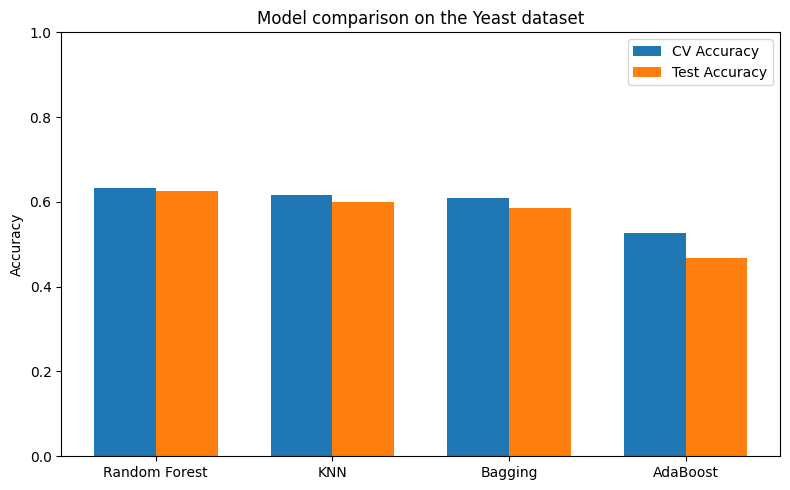

In [26]:
# Bar chart comparing CV vs test accuracy across models
x_pos = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width/2, results_df["CV Accuracy"], width, label="CV Accuracy")
plt.bar(x_pos + width/2, results_df["Test Accuracy"], width, label="Test Accuracy")

plt.xticks(x_pos, results_df["Model"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model comparison on the Yeast dataset")
plt.legend()
plt.tight_layout()
plt.show()

# Sensitivity Analysis

To better understand how the Random Forest model uses individual features to make predictions, we perform a sensitivity analysis on the most important feature (`alm`). The procedure: hold all other features fixed at their dataset-wide average values, then sweep `alm` across its full range. At each value, we use `predict_proba` to record the model's predicted probability for every class. The resulting plot shows how the predicted compartment shifts as the membrane-spanning signal increases.

In [27]:
# Compute the dataset-wide average for each feature.
# These are the values we'll hold constant while sweeping the most important feature.
feature_means = X.mean()
print(feature_means)

mcg    0.500121
gvh    0.499933
alm    0.500034
mit    0.261186
erl    0.504717
pox    0.007500
vac    0.499885
nuc    0.276199
dtype: float64


In [28]:
# Sweep alm across its full range, holding all other features at their average values.
alm_values = np.linspace(0.0, 1.0, 51)  # 51 evenly spaced values from 0 to 1

# Build a list of synthetic proteins, each with average features but different alm
candidates = []
for alm_val in alm_values:
    candidate = feature_means.copy()
    candidate["alm"] = alm_val
    candidates.append(candidate)

# Stack them into a dataframe (one row per synthetic protein)
candidates_df = pd.DataFrame(candidates)

# Get predicted probability for each class at each alm value
probs = best_rf.predict_proba(candidates_df)

# Wrap into a dataframe for easy plotting
prob_df = pd.DataFrame(probs, columns=best_rf.classes_, index=alm_values)
prob_df.index.name = "alm"

prob_df.head()

,CYT,ERL,EXC,ME1,ME2,ME3,MIT,NUC,POX,VAC
alm,,,,,,,,,,
0.00,0.034097,0.0,0.0,0.003333,0.007939,0.801718,0.028705,0.080583,0.001215,0.04241
0.02,0.034097,0.0,0.0,0.003333,0.007939,0.801718,0.028705,0.080583,0.001215,0.04241
0.04,0.034097,0.0,0.0,0.003333,0.007939,0.801718,0.028705,0.080583,0.001215,0.04241
0.06,0.034097,0.0,0.0,0.003333,0.007939,0.801718,0.028705,0.080583,0.001215,0.04241
0.08,0.034097,0.0,0.0,0.003333,0.007939,0.801718,0.028705,0.080583,0.001215,0.04241


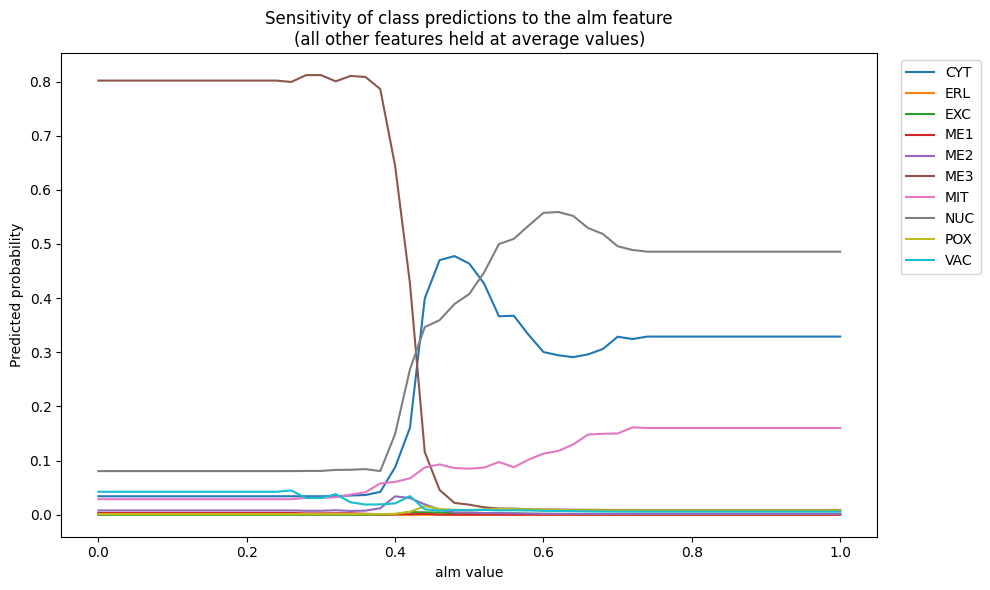

In [29]:
# Plot how predicted probability of each class changes as alm sweeps from 0 to 1
plt.figure(figsize=(10, 6))
for class_name in prob_df.columns:
    plt.plot(prob_df.index, prob_df[class_name], label=class_name)

plt.xlabel("alm value")
plt.ylabel("Predicted probability")
plt.title("Sensitivity of class predictions to the alm feature\n(all other features held at average values)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The sensitivity analysis shows the Random Forest's predicted class shifts through three sections as alm increases: ME3 at low values, CYT in a middle range around alm ≈ 0.45, and NUC at high values. Notably, increasing alm alone does not push the model toward the other membrane classes (ME1, ME2), suggesting that membrane localization predictions depend on a combination of features other than alm in isolation.

# Discussion

In [30]:
# Mean value of each feature, grouped by localization class.
# This shows the "feature profile" for proteins that end up in each compartment.
df_clean.groupby("name").mean().round(3)

,mcg,gvh,alm,mit,erl,pox,vac,nuc
name,,,,,,,,
CYT,0.481,0.470,0.535,0.227,0.504,0.001,0.499,0.257
ERL,0.792,0.772,0.482,0.336,1.000,0.000,0.546,0.246
EXC,0.735,0.717,0.493,0.292,0.500,0.000,0.456,0.227
ME1,0.789,0.757,0.376,0.312,0.500,0.000,0.513,0.268
ME2,0.722,0.603,0.415,0.283,0.510,0.000,0.510,0.245
ME3,0.431,0.490,0.364,0.213,0.503,0.000,0.510,0.270
MIT,0.521,0.533,0.517,0.404,0.500,0.009,0.502,0.241
NUC,0.452,0.456,0.529,0.228,0.503,0.000,0.494,0.332
POX,0.521,0.508,0.507,0.248,0.500,0.423,0.503,0.234


Per-class feature averages reveal that ERL has erl=1.000 (vs 0.500 elsewhere) and POX has pox=0.423 (vs ~0 elsewhere), making them essentially binary class flags, while NUC has only modestly elevated nuc (0.332 vs ~0.25), explaining why CYT and NUC are so often confused.

Random Forest achieved the best test accuracy (62.6%), narrowly outperforming KNN (60.0%). 

Bagging with a KNN base learner did not improve on plain KNN (58.6%), implying the base KNN model was already stable. 

AdaBoost performed substantially worse (46.8%), failing to predict five of the ten classes and collapsing most predictions onto the dominant NUC class. 

The close agreement between cross-validated and test accuracies across all four models indicates that none of the models suffered from significant overfitting.

The Random Forest's feature importance results identify which features most strongly drive the model's predictions (alm, mit, mcg, gvh make up ~76%), so designing a protein for a target compartment would mean tuning those high-importance features to match the values typical of that compartment. For example, to design a nuclear (NUC) protein, the per-class averages suggest targeting low mcg and gvh (~0.45) along with elevated alm (~0.53) and a higher-than-typical nuc score (~0.33). However, NUC and CYT have nearly identical values across the four most important features, so distinguishing between them requires looking further down the importance ranking to nuc (the 5th most important feature), where NUC's average (0.332) finally separates noticeably from CYT's (0.257).